# Topic Modelling
(Francesca)

In this notebook, I explore topic modeling using Latent Dirichlet Allocation (LDA) on a set of documents that include subtitles from 21 Disney and 17 Studio Ghibli movies. Topic modelling is performed on 127 documents for Studio Disney and 102 documents for Studio Ghibli. The number of documents was increased by splitting each movie into 6 parts of equal size, which aims to improve the performance of the lda models. 

The goal is to identify the main topics present in the subtitles and compare the topics between the two studios.

---

The notebook is structured as follows:

1. **Disney Topic Modelling**  
   1.1 Preprocessing of the Disney data  
   1.2 Document-term matrix  
   1.3 Apply the LDA model  
   1.4 Examine the topics  
   1.5 Visualize the topics  

2. **Studio Ghibli Topic Modelling**  
   2.1 Preprocessing of the Studio Ghibli data  
   2.2 Document-term matrix  
   2.3 Apply the LDA model  
   2.4 Examine the topics  
   2.5 Visualize the topics  

3. **Comparison between LDA Disney and LDA Studio Ghibli**  
   3.1 Comparison of Coherence Scores  
   3.2 Comparison of Topics  


References:
1. ChatGPT: https://chatgpt.com/share/6826fc0b-ea4c-800e-8f39-9801942680cf
2. Notebook: https://github.com/bloemj/AUC_TM_2025/blob/main/notebooks/12_Clustering_TopicModelling.ipynb

### Imports Libraries and Stopwords

#### Imports

In [118]:
# Imports

# Preprocessing imports
import os
import nltk
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from Stopwords_for_lda import stopwords_mallet, disney_main_characters, custom_movie_words, ghibli_main_characters

# Document-matrix imports
from gensim import corpora
import itertools
from collections import Counter
from gensim import models
from gensim.models.ldamodel import LdaModel

# Evaluation imports
from gensim.models import CoherenceModel

# Visualization imports
import numpy as np
import matplotlib.pyplot as plt

In [119]:
# # Only Run once
# nltk.download('wordnet') 
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('universal_tagset', download_dir='/home/codespace/nltk_data')
# nltk.download('stopwords')

#### Stopwords:

In [120]:
# Stopwords for Disney
disney_main_characters = {
    "abby_mallard", "aladdin", "andy", "anna", "ariel", "beast", "belle", "bellwether", "blue_fairy",
    "bo_peep", "bogo", "buck_cluck", "bunny", "buzz", "calhoun", "chicken_little", "chip", "clawhauser",
    "cogsworth", "cobra_bubbles", "david", "duke", "dumbo", "elephant", "elsa", "eric", "felix", "fish",
    "flash", "flit", "flounder", "flynn", "gaston", "genie", "geppetto", "gothel", "gramma_tala",
    "grandmother_willow", "hades", "hamm", "hans", "hei_hei", "hercules", "honest_john", "iago", "jafar",
    "jasmine", "jessie", "jiminy", "jiminy_cricket", "john", "john_smith", "judy", "jumba", "knowsmore",
    "lefou", "lilo", "lumiere", "maximus", "meeko", "megara", "moana", "mr_big", "mrs_jumbo", "mrs_potts",
    "maui", "mufasa", "nakoma", "nala", "nani", "nick", "olaf", "pain", "panic", "pascal", "phil", "pinocchio",
    "pleakley", "pocahontas", "potato_head", "pua", "pumbaa", "rafiki", "ralph", "rapunzel", "ratcliffe",
    "rex", "ringmaster", "runt", "sultan", "scar", "scuttle", "sebastian", "shank", "simba", "slinky",
    "spamley", "stitch", "stromboli", "sven", "tamatoa", "te_fiti", "timothy", "timon", "toy", "triton",
    "ursula", "vanellope", "woody", "yesss", "zazu", "zeus"
}


In [121]:
# Stopwords for Studio Ghibli

ghibli_main_characters = {
    'αrchmage', ' τenar', 'arrietty', 'arren', 'ashitaka', 'asbel', 'anna',
    'chihiro', 'cob', 'eboshi', 'fio', 'ged', 'haku', 'haνe', 'heron', 'jiji', 'jiro',
    'kiki', 'laputa', 'lisa', 'mahito', 'marnie', 'mei', 'naoko', 'nausicaa', 'natsuko',
    'no_face', 'pazu', 'ponyo', 'porco', 'room', 'san', 'satsuki', 'seiji', 'seita',
    'setsuko', 'sheeta', 'shizuku', 'sho', 'shun', 'sparrowhawk', 'sosuke', 'taeko',
    'tenar', 'tombo', 'totoro', 'umi', 'yubaba', 'τherru'
}


In [122]:
# Stopwords from standard-mallet-en.txt
stopwords_mallet = {
    "a", "able", "about", "above", "according", "accordingly", "across", "actually", "after", "afterwards",
    "again", "against", "all", "allow", "allows", "almost", "alone", "along", "already", "also", "although",
    "always", "am", "among", "amongst", "an", "and", "another", "any", "anybody", "anyhow", "anyone",
    "anything", "anyway", "anyways", "anywhere", "apart", "appear", "appreciate", "appropriate", "are",
    "around", "as", "aside", "ask", "asking", "associated", "at", "available", "away", "awfully", "b", "be",
    "became", "because", "become", "becomes", "becoming", "been", "before", "beforehand", "behind", "being",
    "believe", "below", "beside", "besides", "best", "better", "between", "beyond", "big", "both", "brief", "but",
    "by", "c", "came", "can", "cannot", "cant", "cause", "causes", "certain", "certainly", "changes", "clearly",
    "co", "com", "come", "comes", "concerning", "consequently", "consider", "considering", "contain",
    "containing", "contains", "corresponding", "could", "course", "currently", "d", "definitely", "described",
    "despite", "did", "different", "do", "does", "doing", "done", "down", "downwards", "during", "e", "each",
    "edu", "eg", "eight", "either", "else", "elsewhere", "enough", "entirely", "especially", "et", "etc", "even",
    "ever", "every", "everybody", "everyone", "everything", "everywhere", "ex", "exactly", "example", "except",
    "f", "far", "few", "fifth", "first", "five", "followed", "following", "follows", "for", "former", "formerly",
    "forth", "four", "from", "further", "furthermore", "g", "get", "gets", "getting", "given", "gives", "go", "gonna"
    "goes", "going", "gone", "got", "gotten", "greetings", "h", "had", "happens", "hardly", "has", "have",
    "having", "he", "hello", "help", "hence", "her", "here", "hereafter", "hereby", "herein", "hereupon",
    "hers", "herself", "hi", "him", "himself", "his", "hither", "hopefully", "how", "howbeit", "however", "i",
    "ie", "if", "ignored", "immediate", "in", "inasmuch", "inc", "indeed", "indicate", "indicated", "indicates",
    "inner", "insofar", "instead", "into", "inward", "is", "it", "its", "itself", "j", "just", "k", "kind", "keep", "keeps",
    "kept", "know", "knows", "known", "l", "last", "lately", "later", "latter", "latterly", "least", "less", "lest",
    "let", "like", "liked", "likely", "little", "look", "looking", "looks", "ltd", "m", "mainly", "many", "may",
    "maybe", "me", "mean", "meanwhile", "merely", "might", "more", "moreover", "most", "mostly", "much",
    "must", "my", "myself", "n", "name", "namely", "nd", "near", "nearly", "necessary", "need", "needs",
    "neither", "never", "nevertheless", "new", "next", "nine", "no", "nobody", "non", "none", "noone", "nor",
    "normally", "not", "nothing", "novel", "now", "nowhere", "o", "obviously", "of", "off", "often", "oh", "ok",
    "okay", "old", "on", "once", "one", "ones", "only", "onto", "or", "other", "others", "otherwise", "ought",
    "our", "ours", "ourselves", "out", "outside", "over", "overall", "own", "p", "particular", "particularly",
    "per", "perhaps", "placed", "please", "plus", "possible", "presumably", "probably", "provides", "q",
    "que", "quite", "qv", "r", "rather", "rd", "re", "really", "reasonably", "regarding", "regardless",
    "regards", "relatively", "respectively", "right", "s", "said", "same", "saw", "say", "saying", "says",
    "second", "secondly", "see", "seeing", "seem", "seemed", "seeming", "seems", "seen", "self", "selves",
    "sensible", "sent", "serious", "seriously", "seven", "several", "shall", "she", "should", "since", "six",
    "so", "some", "somebody", "somehow", "someone", "something", "sometime", "sometimes", "somewhat",
    "somewhere", "soon", "sorry", "specified", "specify", "specifying", "still", "sub", "such", "sup", "sure",
    "t", "take", "taken", "tell", "tends", "th", "than", "thank", "thanks", "thanx", "that", "thats", "the",
    "their", "theirs", "them", "themselves", "then", "thence", "there", "thereafter", "thereby", "therefore",
    "therein", "theres", "thereupon", "these", "they", "think", "third", "this", "thorough", "thoroughly",
    "those", "though", "three", "through", "throughout", "thru", "thus", "to", "together", "too", "took",
    "toward", "towards", "tried", "tries", "truly", "try", "trying", "twice", "two", "u", "un", "under",
    "unfortunately", "unless", "unlikely", "until", "unto", "up", "upon", "us", "use", "used", "useful",
    "uses", "using", "usually", "uucp", "v", "value", "various", "very", "via", "viz", "vs", "w", "wait", "want",
    "wants", "was", "way", "we", "welcome", "well", "went", "were", "what", "whatever", "when", "whence",
    "whenever", "where", "whereafter", "whereas", "whereby", "wherein", "whereupon", "wherever",
    "whether", "which", "while", "whither", "who", "whoever", "whole", "whom", "whose", "why", "will",
    "willing", "wish", "with", "within", "without", "wonder", "whoa", "would", "x", "y", "yes", "yet", "you", "your",
    "yours", "yourself", "yourselves", "yeah", "z", "zero"
}


In [123]:
# Custom stopwords for movies

custom_movie_words = {
    "αnd", "actor", "animation", "animator", "animator", "animator", "animator", "anime", "bit", "boy", "case", "character",
    "computer", "day", "disney", "effect", "film", "frame", "gina", "ghibli", "girl", "gonna", "granduncle", "grasp",
    "grunt", "guy", "hey", "hopps", "howard", "huh", "hurry", "idea", "japan", "japanse", "line", "lot", "mei",
    "minute", "moment", "movie", "pig", "point", "second", "scene", "sequence", "sir", "song", "story", "studio",
    "studio_ghibli", "term", "thing", "things", "time", "voice", "αrren"
}


## 1. DISNEY TOPIC MODELLING  

### 1.1 Preprocessing of the Disney data

The following code performs the prepocessing for the corpus of Disney movie scripts. 
1. Load Data: The documents are loaded from the data_split/disney directory, which is tokenized into word-level representations.
2. Lemmatization: Each token is lemmatized with Part-of-Speech (POS) awareness, using a mapping from the Universal POS tagset to WordNet-compatible tags.
3. Filtering: Tokens are filtered to remove common stopwords, names of main Disney characters, and domain-specific movie terms. Only nouns and adjectives longer than two characters are retained for further analysis.

In [124]:
# Import Data
disney_data_folder = 'data_split/disney'

In [125]:
# WordNetLemmatizer, POS tags and stop words
un2wn_mapping = {"VERB": wn.VERB, "NOUN": wn.NOUN, "ADJ": wn.ADJ, "ADV": wn.ADV}
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Filtering function
def disney_filter_token(token):
    return token not in stopwords_mallet and token not in disney_main_characters and token not in custom_movie_words

In [126]:
# Creation of word lists (raw_documents) and the filenames (document_names) for final visualization

disney_raw_documents = []
disney_document_names = []

for filename in sorted(os.listdir(disney_data_folder)):  
    file_path = os.path.join(disney_data_folder, filename)
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            tokens = f.read().strip().split()
            disney_raw_documents.append(tokens)
            disney_document_names.append(filename)

In [127]:
# Lemmatize with POS tagging 
disney_movie_docs = []

for words in disney_raw_documents:
    disney_lemmatized_doc = []
    tagged = nltk.pos_tag(words, tagset="universal")
    for word, tag in tagged:
        if tag in un2wn_mapping:
            lemma = lemmatizer.lemmatize(word, pos=un2wn_mapping[tag])
        else:
            lemma = lemmatizer.lemmatize(word)
        lemma = lemma.lower()
        if disney_filter_token(lemma) and tag in {"NOUN"} and len(lemma) > 2: 
            disney_lemmatized_doc.append(lemma)
    disney_movie_docs.append(disney_lemmatized_doc)

print(f"Total documents: {len(disney_movie_docs)}")

Total documents: 126


### 1.2 Constuct a document-term matrix

In [128]:
# Create dictionary representation of documents
disney_movie_dictionary = corpora.Dictionary(disney_movie_docs)

# Filter out words that occur in less than 2 documents, or more than 80% of the documents.
disney_movie_dictionary.filter_extremes(no_below=2, no_above=0.8)
print('Number of unique tokens:', len(disney_movie_dictionary))

# Bag-of-words representation of the documents
disney_movie_bow_corpus = [disney_movie_dictionary.doc2bow(d) for d in disney_movie_docs]

Number of unique tokens: 2204


### 1.2 Apply the LDA model

In [129]:
disney_movie_ldamodel = models.ldamodel.LdaModel(
    disney_movie_bow_corpus,
    num_topics=9,
    id2word=disney_movie_dictionary,
    passes=40,
    random_state=42  
)

### 1.3 Examine the topics

In [130]:
# Top words in each topic (words and weights)
for topic_num, topic_words in disney_movie_ldamodel.show_topics(formatted=False, num_words=8):
    print(f" Topic #{topic_num}")
    for word, prob in topic_words:
        print(f"   {word:<15} ({prob:.4f})")


 Topic #0
   music           (0.0088)
   water           (0.0084)
   part            (0.0084)
   people          (0.0071)
   work            (0.0070)
   piece           (0.0063)
   shot            (0.0062)
   job             (0.0061)
 Topic #1
   dig             (0.0299)
   savage          (0.0271)
   predator        (0.0157)
   gold            (0.0141)
   officer         (0.0136)
   world           (0.0122)
   men             (0.0120)
   river           (0.0102)
 Topic #2
   prince          (0.0249)
   dream           (0.0238)
   princess        (0.0165)
   mother          (0.0130)
   heart           (0.0105)
   world           (0.0096)
   power           (0.0081)
   year            (0.0081)
 Topic #3
   heart           (0.0399)
   sea             (0.0202)
   hook            (0.0177)
   boat            (0.0170)
   fiti            (0.0141)
   people          (0.0128)
   island          (0.0124)
   dad             (0.0114)
 Topic #4
   bobbidi         (0.0137)
   dream           (0.0125

In [131]:
# Topic distribution for each document
for doc_topics in disney_movie_ldamodel.get_document_topics(disney_movie_bow_corpus):
    print(doc_topics)

[(2, 0.58023375), (5, 0.41573313)]
[(2, 0.57560265), (4, 0.4196225)]
[(2, 0.9936918)]
[(2, 0.99578524)]
[(2, 0.99476826)]
[(2, 0.99451)]
[(2, 0.9509071), (4, 0.04296447)]
[(7, 0.99305224)]
[(2, 0.14570372), (5, 0.846665)]
[(4, 0.9930522)]
[(2, 0.9911058)]
[(0, 0.1005573), (2, 0.57017744), (4, 0.07873021), (5, 0.16037728), (6, 0.08632251)]
[(2, 0.20759912), (3, 0.684048), (8, 0.10325995)]
[(8, 0.993602)]
[(8, 0.9927107)]
[(3, 0.43626127), (5, 0.55639565)]
[(2, 0.15848404), (3, 0.3845005), (5, 0.16758627), (8, 0.2848719)]
[(3, 0.9934124)]
[(0, 0.6319096), (5, 0.36296934)]
[(5, 0.4176529), (7, 0.57768685)]
[(5, 0.877966), (8, 0.117169075)]
[(0, 0.5951447), (5, 0.39852712)]
[(0, 0.13755156), (5, 0.8032318), (8, 0.055147726)]
[(5, 0.99378026)]
[(2, 0.9714556), (3, 0.022864236)]
[(6, 0.992399)]
[(2, 0.9918409)]
[(2, 0.06348825), (4, 0.93066156)]
[(6, 0.9926506)]
[(2, 0.57371384), (4, 0.41873065)]
[(6, 0.9856558)]
[(6, 0.9895354)]
[(8, 0.98798215)]
[(0, 0.30998197), (6, 0.101027176), (8, 0.57

### 1.4 Evaluate the model with Coherence Score

In [148]:
# Compute coherence score (how interpretable the topics are — higher is better)
disney_coherence_model_lda = CoherenceModel(
    model=disney_movie_ldamodel,
    texts=disney_movie_docs,
    dictionary=disney_movie_dictionary,
    coherence='c_v' 
)

print('\nCoherence score:', disney_coherence_model_lda.get_coherence())


# Initialize empty lists, disney coherence will be used in for later visualization
disney_topics = list(range(2, 11))
disney_coherence = []

for k in disney_topics:
    model = LdaModel(disney_movie_bow_corpus, num_topics=k, id2word=disney_movie_dictionary, passes=40, random_state=42)
    coherence_model = CoherenceModel(model=model, texts=disney_movie_docs, dictionary=disney_movie_dictionary, coherence='c_v')
    coherence = coherence_model.get_coherence()
    disney_coherence.append(coherence)
    print(f"Topics: {k}, Coherence: {coherence:.4f}")


Coherence score: 0.34413381173104174
Topics: 2, Coherence: 0.2487
Topics: 3, Coherence: 0.2644
Topics: 4, Coherence: 0.2609
Topics: 5, Coherence: 0.2879
Topics: 6, Coherence: 0.3650
Topics: 7, Coherence: 0.3530
Topics: 8, Coherence: 0.3223
Topics: 9, Coherence: 0.3441
Topics: 10, Coherence: 0.3862


### 1.5 Visualize the topics

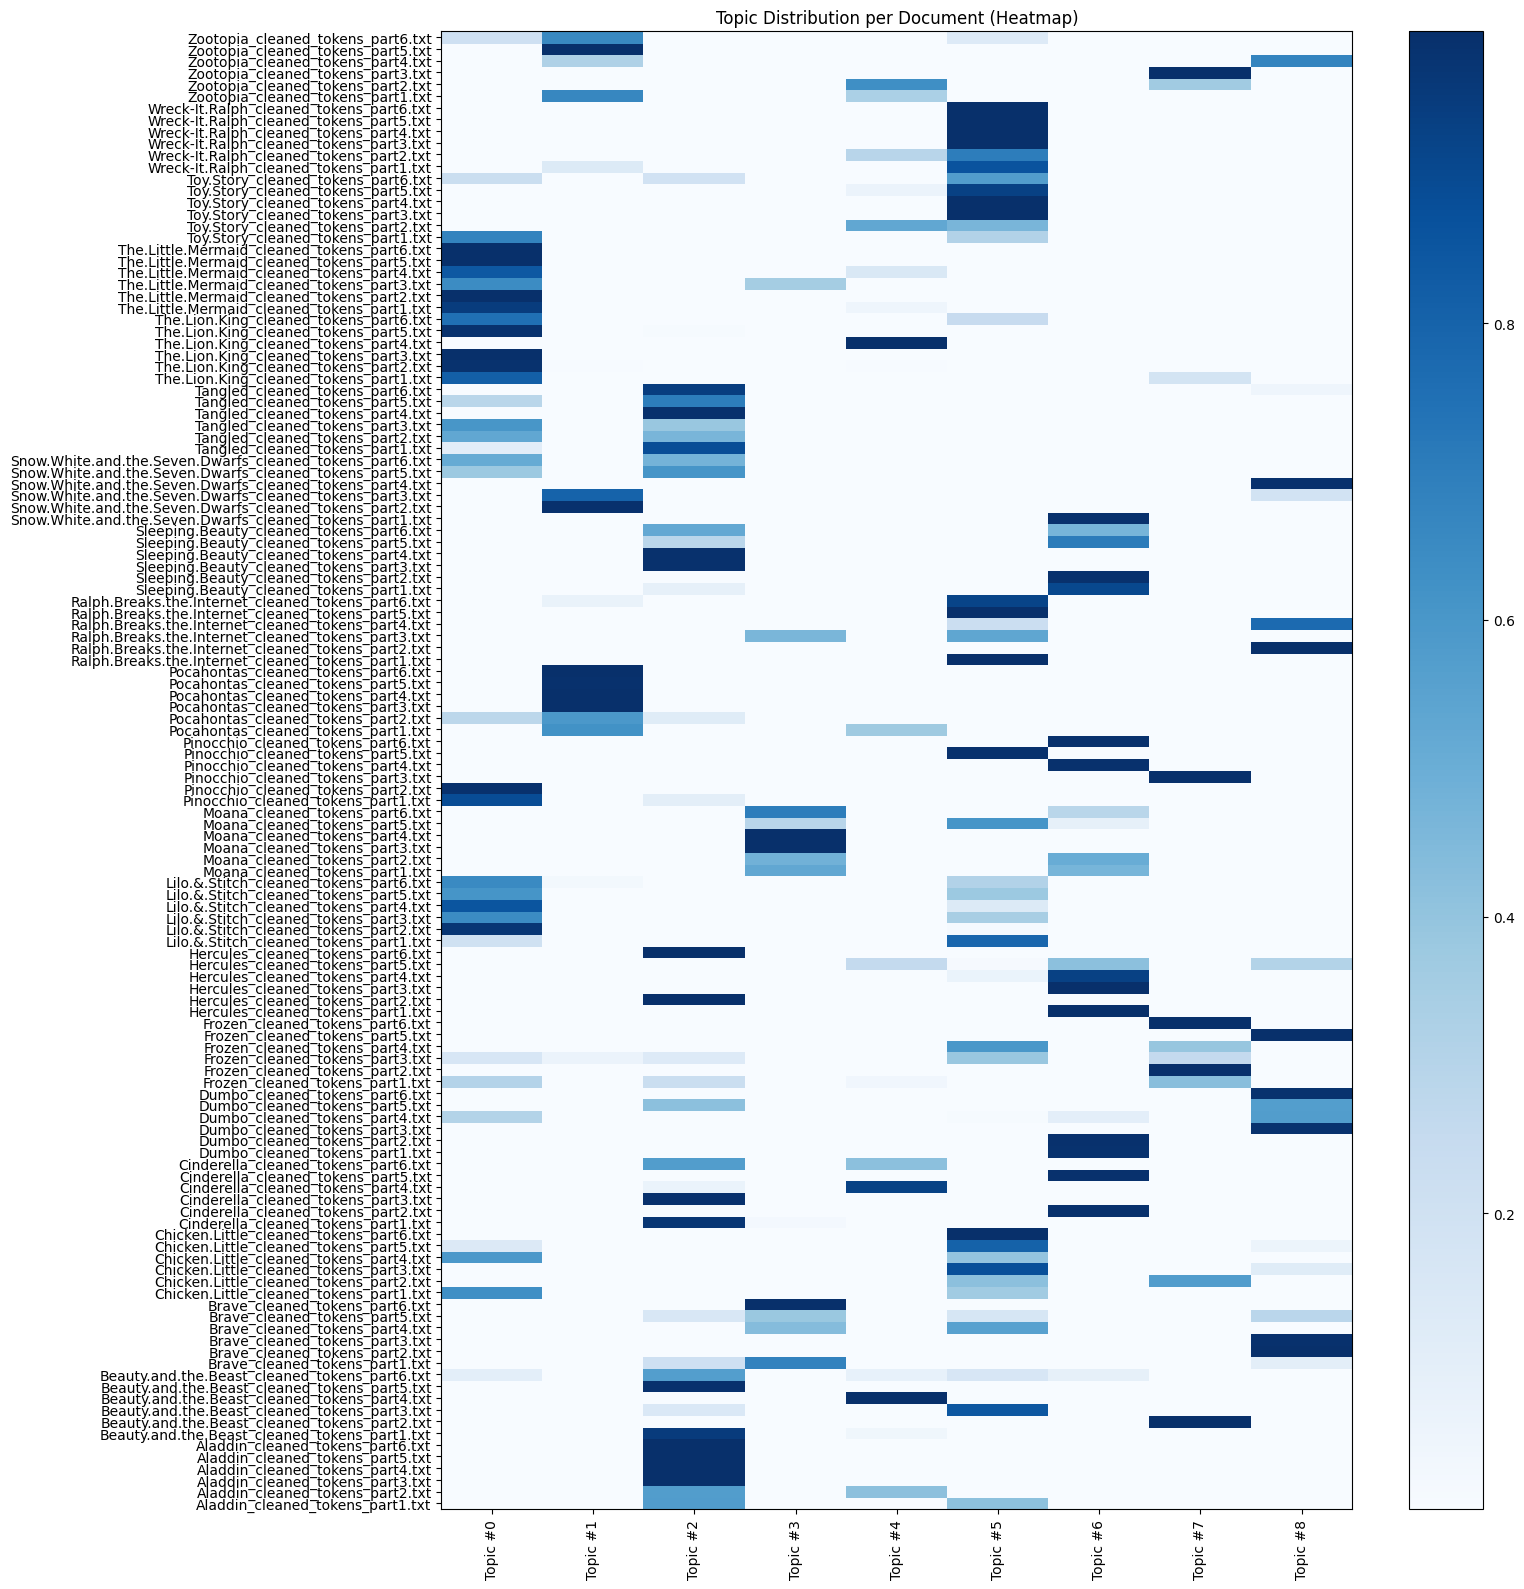

In [133]:
# Create a document-topic matrix: rows = documents, columns = topics
disney_doc2topics = np.zeros((len(disney_movie_docs), disney_movie_ldamodel.num_topics))

# Fill in topic probabilities for each document
for di, doc_topics in enumerate(disney_movie_ldamodel.get_document_topics(disney_movie_bow_corpus, minimum_probability=0)):
    for ti, v in doc_topics:
        disney_doc2topics[di, ti] = v


# Heatmap
disney_docs_id = disney_document_names
disney_num_topics = disney_movie_ldamodel.num_topics

fig = plt.figure(figsize=(16, 16))
plt.pcolor(disney_doc2topics, cmap='Blues')
plt.yticks(np.arange(disney_doc2topics.shape[0]) + 0.5, disney_docs_id, fontsize=10)
plt.xticks(np.arange(disney_num_topics) + 0.5, [f"Topic #{n}" for n in range(disney_num_topics)], rotation=90)
plt.colorbar()
plt.title("Topic Distribution per Document (Heatmap)")
plt.tight_layout()
plt.show()

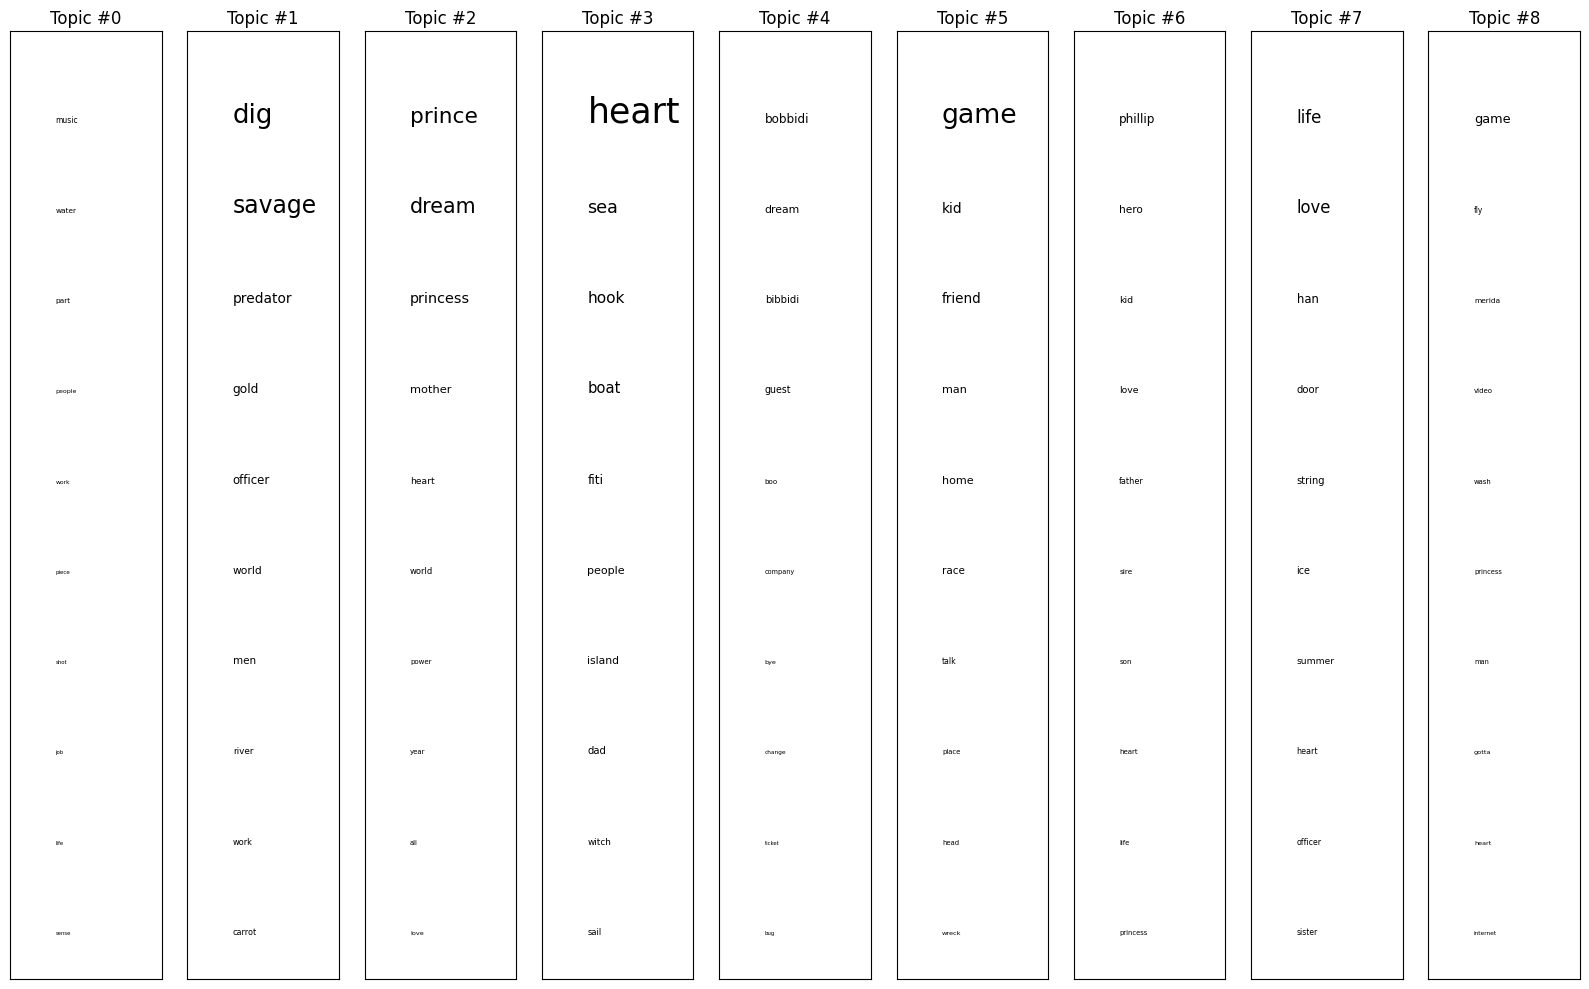

In [134]:
# Plot top words per topic

disney_fig = plt.figure(figsize=(16, 10))
num_top_words = 10


topic2top_words = dict(disney_movie_ldamodel.show_topics(formatted=False, num_words=num_top_words))
fontsize_base = 25 / max([w[0][1] for w in topic2top_words.values()])  

for topic, words_shares in topic2top_words.items():
    plt.subplot(1, disney_movie_ldamodel.num_topics, topic + 1)
    plt.ylim(0, num_top_words + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Topic #{topic}')
    for i, (word, share) in enumerate(words_shares):
        plt.text(0.3, num_top_words - i - 0.5, word, fontsize=fontsize_base * share)

plt.tight_layout()
plt.show()

## 2. Studio Ghibli Topic Modelling

### 2.1 Preprocessing of the Studio Ghibli data

The following code performs the prepocessing for the corpus of Disney movie scripts. 
1. Load Data: The documents are loaded from the data_split/ghibli directory, which is tokenized into word-level representations.
2. Lemmatization: Each token is lemmatized with Part-of-Speech (POS) awareness, using a mapping from the Universal POS tagset to WordNet-compatible tags.
3. Filtering: Tokens are filtered to remove common stopwords, names of main Disney characters, and domain-specific movie terms. Only nouns and adjectives longer than two characters are retained for further analysis.

In [135]:
# Import data
ghibli_data_folder = 'data_split/ghibli'

In [136]:
# WordNetLemmatizer, POS tags and stop words
un2wn_mapping = {"VERB": wn.VERB, "NOUN": wn.NOUN, "ADJ": wn.ADJ, "ADV": wn.ADV}
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Filtering function
def ghibli_filter_token(token):
    return token not in stopwords_mallet and token not in ghibli_main_characters and token not in custom_movie_words

In [137]:
# Creation of word lists (raw_documents) and the filenames (document_names) for final visualization

ghibli_raw_documents = []
ghibli_document_names = []

for filename in sorted(os.listdir(ghibli_data_folder)):  
    file_path = os.path.join(ghibli_data_folder, filename)
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            tokens = f.read().strip().split()
            ghibli_raw_documents.append(tokens)
            ghibli_document_names.append(filename)

In [138]:
# Lemmatize with POS awareness
ghibli_movie_docs = []

for words in ghibli_raw_documents:
    lemmatized_doc = []
    tagged = nltk.pos_tag(words, tagset="universal")
    for word, tag in tagged:
        if tag in un2wn_mapping:
            lemma = lemmatizer.lemmatize(word, pos=un2wn_mapping[tag])
        else:
            lemma = lemmatizer.lemmatize(word)
        lemma = lemma.lower()
        if ghibli_filter_token(lemma) and tag in {"NOUN", "ADJ"} and len(lemma) > 2: 
            lemmatized_doc.append(lemma)
    ghibli_movie_docs.append(lemmatized_doc)

print(f"Total documents: {len(ghibli_movie_docs)}")

Total documents: 102


### 2.1 Constuct a document-term matrix

In [139]:
# Create dictionary representation of documents
ghibli_movie_dictionary = corpora.Dictionary(ghibli_movie_docs)

# Filter out words that occur in less than 2 documents, or more than 80% of the documents.
ghibli_movie_dictionary.filter_extremes(no_below=3, no_above=0.8)
print('Number of unique tokens:', len(ghibli_movie_dictionary))

# Bag-of-words representation of the documents
ghibli_movie_bow_corpus = [ghibli_movie_dictionary.doc2bow(d) for d in ghibli_movie_docs]


Number of unique tokens: 1215


### 2.2 Apply the LDA model

In [140]:
ghibli_movie_ldamodel = models.ldamodel.LdaModel(ghibli_movie_bow_corpus, num_topics=5, id2word = ghibli_movie_dictionary, passes = 40, random_state=42)

### 2.3 Examine the topics

In [141]:
# Top words in each topic (words and weights)
for topic_num, topic_words in ghibli_movie_ldamodel.show_topics(formatted=False, num_words=8):
    print(f"\n Topic #{topic_num}")
    for word, prob in topic_words:
        print(f"   {word:<15} ({prob:.4f})")


 Topic #0
   forest          (0.0222)
   human           (0.0203)
   spirit          (0.0162)
   stop            (0.0112)
   lady            (0.0103)
   stone           (0.0102)
   life            (0.0096)
   milady          (0.0096)

 Topic #1
   princess        (0.0287)
   sea             (0.0181)
   life            (0.0168)
   valley          (0.0161)
   decay           (0.0156)
   wind            (0.0127)
   lord            (0.0127)
   ship            (0.0114)

 Topic #2
   plane           (0.0142)
   work            (0.0122)
   beautiful       (0.0106)
   witch           (0.0091)
   air             (0.0076)
   money           (0.0073)
   man             (0.0073)
   great           (0.0069)

 Topic #3
   home            (0.0159)
   house           (0.0115)
   school          (0.0111)
   mother          (0.0103)
   work            (0.0102)
   people          (0.0101)
   mom             (0.0099)
   great           (0.0097)

 Topic #4
   home            (0.0156)
   country         (0

In [142]:
# Topic distribution for each document
for doc_topics in ghibli_movie_ldamodel.get_document_topics(ghibli_movie_bow_corpus):
    print(doc_topics)

[(0, 0.30384412), (2, 0.29817623), (4, 0.38930994)]
[(0, 0.8215679), (4, 0.1740472)]
[(0, 0.99402124)]
[(0, 0.54695773), (1, 0.10961949), (3, 0.34072405)]
[(0, 0.45263398), (1, 0.38738137), (3, 0.15721467)]
[(0, 0.83407617), (1, 0.1617288)]
[(2, 0.27275962), (4, 0.7225774)]
[(4, 0.9941789)]
[(0, 0.026635567), (1, 0.045684543), (2, 0.06233196), (3, 0.18786003), (4, 0.67748785)]
[(4, 0.9951997)]
[(4, 0.9941454)]
[(4, 0.99454045)]
[(0, 0.11576411), (3, 0.8778763)]
[(3, 0.63563216), (4, 0.35737622)]
[(4, 0.9917777)]
[(4, 0.98922396)]
[(0, 0.27141714), (3, 0.7216557)]
[(4, 0.9907737)]
[(2, 0.06313038), (4, 0.9335951)]
[(2, 0.9953763)]
[(2, 0.8329814), (3, 0.16307208)]
[(2, 0.4891818), (3, 0.27872112), (4, 0.22929753)]
[(2, 0.50510097), (3, 0.49092373)]
[(2, 0.99518585)]
[(0, 0.5540837), (3, 0.43865922)]
[(3, 0.99030644)]
[(0, 0.2579136), (3, 0.56470656), (4, 0.17208819)]
[(2, 0.021348218), (3, 0.9719826)]
[(3, 0.9899795)]
[(0, 0.14651293), (3, 0.84254915)]
[(1, 0.99588937)]
[(1, 0.99572486)

### 2.4 Evaluate the model with Coherence Score

In [ ]:
# Compute coherence score (how interpretable the topics are — higher is better)
ghibli_coherence_model_lda = CoherenceModel(
    model=ghibli_movie_ldamodel,
    texts=ghibli_movie_docs,
    dictionary=ghibli_movie_dictionary,
    coherence='c_v'  
)

print('\nCoherence score:', ghibli_coherence_model_lda.get_coherence())

# Calculate coherence score for different numbers of topics
ghibli_topics = list(range(2, 11))
ghibli_coherence = []

for k in ghibli_topics:
    model = LdaModel(ghibli_movie_bow_corpus, num_topics=k, id2word=ghibli_movie_dictionary, passes=40, random_state=42)
    coherence_model = CoherenceModel(model=model, texts=ghibli_movie_docs, dictionary=ghibli_movie_dictionary, coherence='c_v')
    coherence = coherence_model.get_coherence()
    ghibli_coherence.append(coherence)
    print(f"Topics: {k}, Coherence: {coherence:.4f}")



Coherence score: 0.41876479847322
Topics: 2, Coherence: 0.2735
Topics: 3, Coherence: 0.3662
Topics: 4, Coherence: 0.4256
Topics: 5, Coherence: 0.4188
Topics: 6, Coherence: 0.4377
Topics: 7, Coherence: 0.3764
Topics: 8, Coherence: 0.3624
Topics: 9, Coherence: 0.4071
Topics: 10, Coherence: 0.4121


### 2.5 Visualize the topics

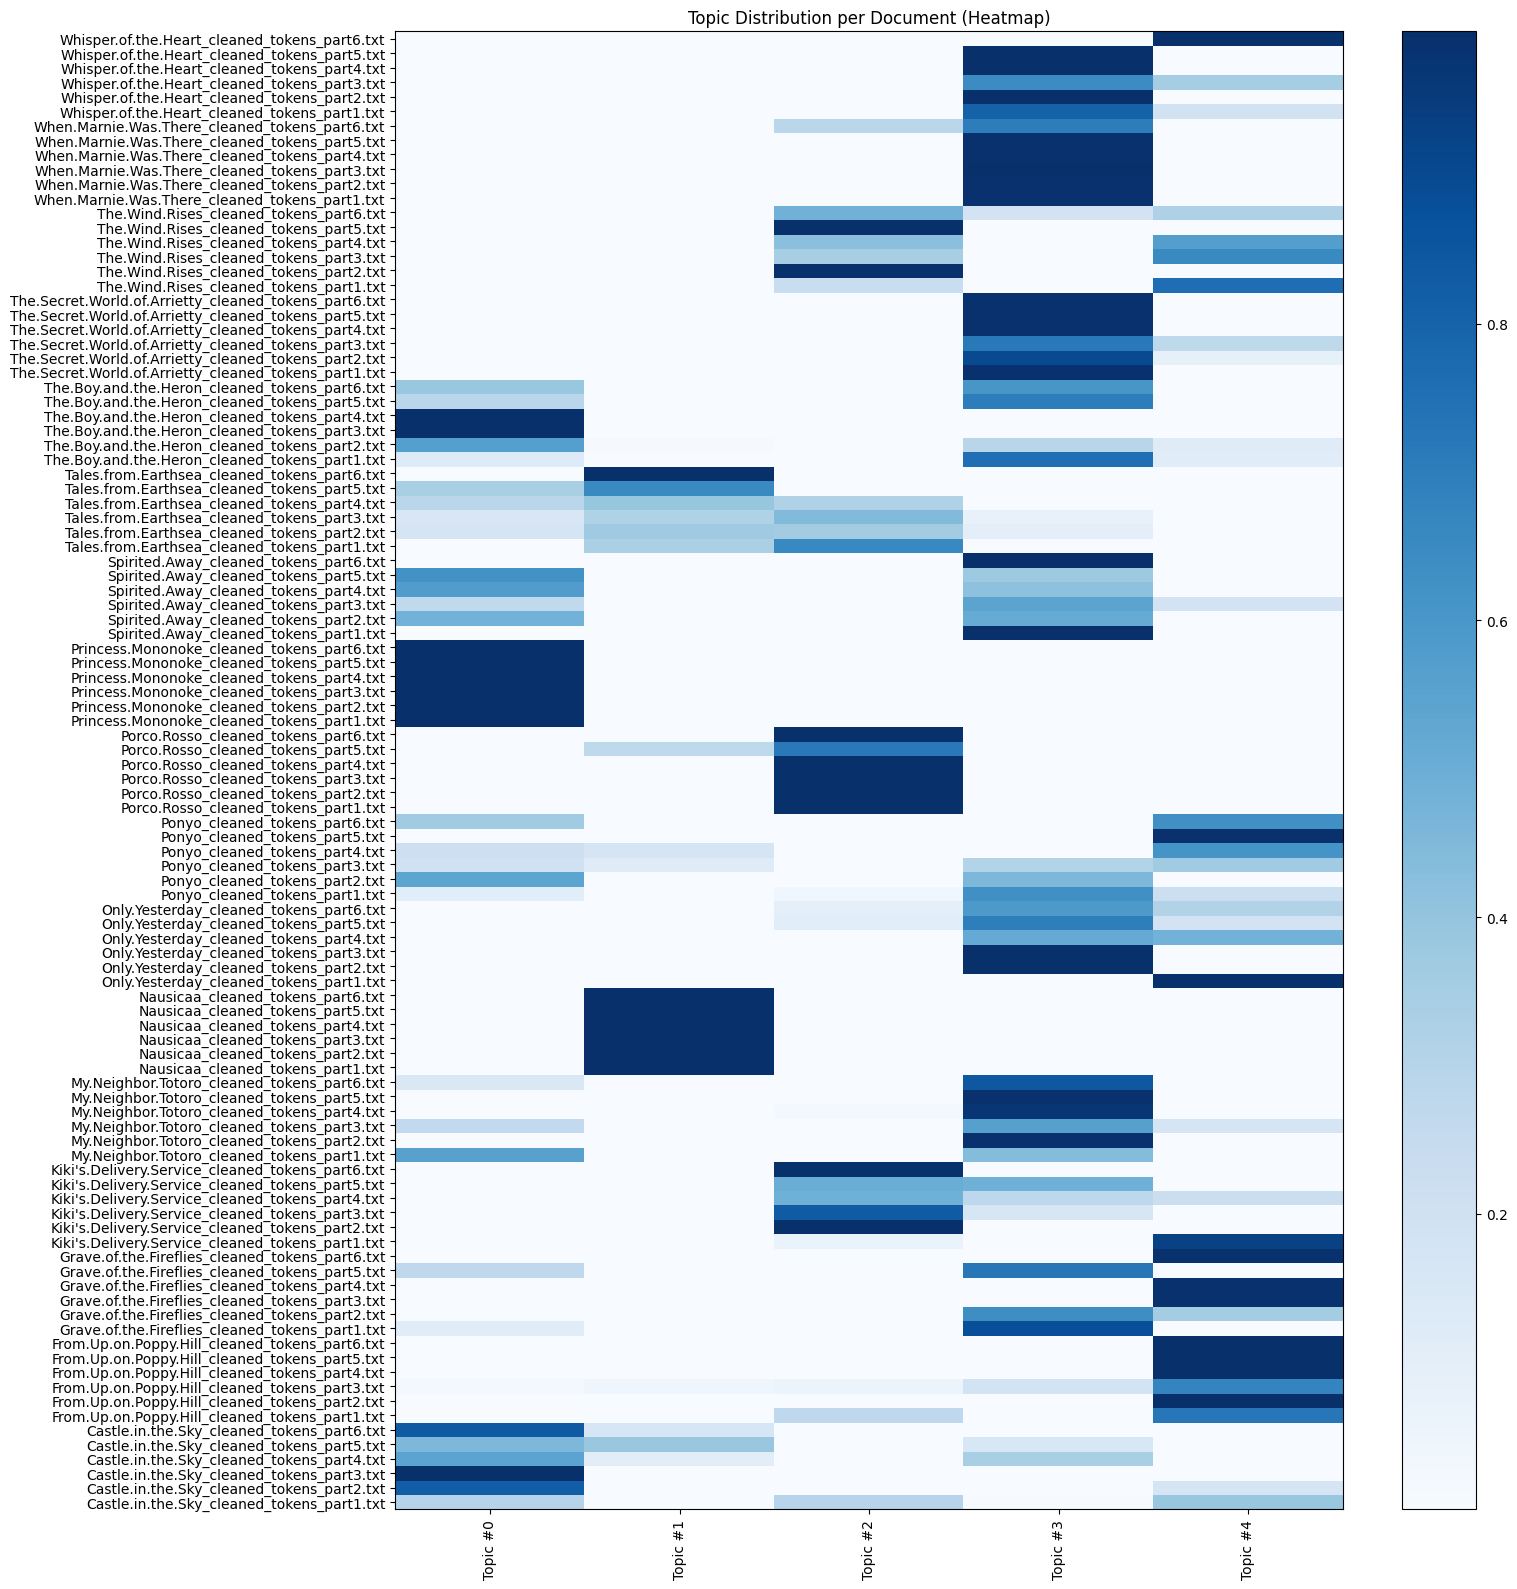

In [144]:

# Create a document-topic matrix: rows = documents, columns = topics
ghibli_doc2topics = np.zeros((len(ghibli_movie_docs), ghibli_movie_ldamodel.num_topics))

# Fill in topic probabilities for each document
for di, doc_topics in enumerate(ghibli_movie_ldamodel.get_document_topics(ghibli_movie_bow_corpus, minimum_probability=0)):
    for ti, v in doc_topics:
        ghibli_doc2topics[di, ti] = v

# Heatmap
ghibli_docs_id = ghibli_document_names
ghibli_num_topics = ghibli_movie_ldamodel.num_topics

fig = plt.figure(figsize=(16, 16))
plt.pcolor(ghibli_doc2topics, cmap='Blues')
plt.yticks(np.arange(ghibli_doc2topics.shape[0]) + 0.5, ghibli_docs_id, fontsize=10)
plt.xticks(np.arange(ghibli_num_topics) + 0.5, [f"Topic #{n}" for n in range(ghibli_num_topics)], rotation=90)
plt.colorbar()
plt.title("Topic Distribution per Document (Heatmap)")
plt.tight_layout()
plt.savefig("ghibli_topic_heatmap.png", dpi=300)
plt.show()

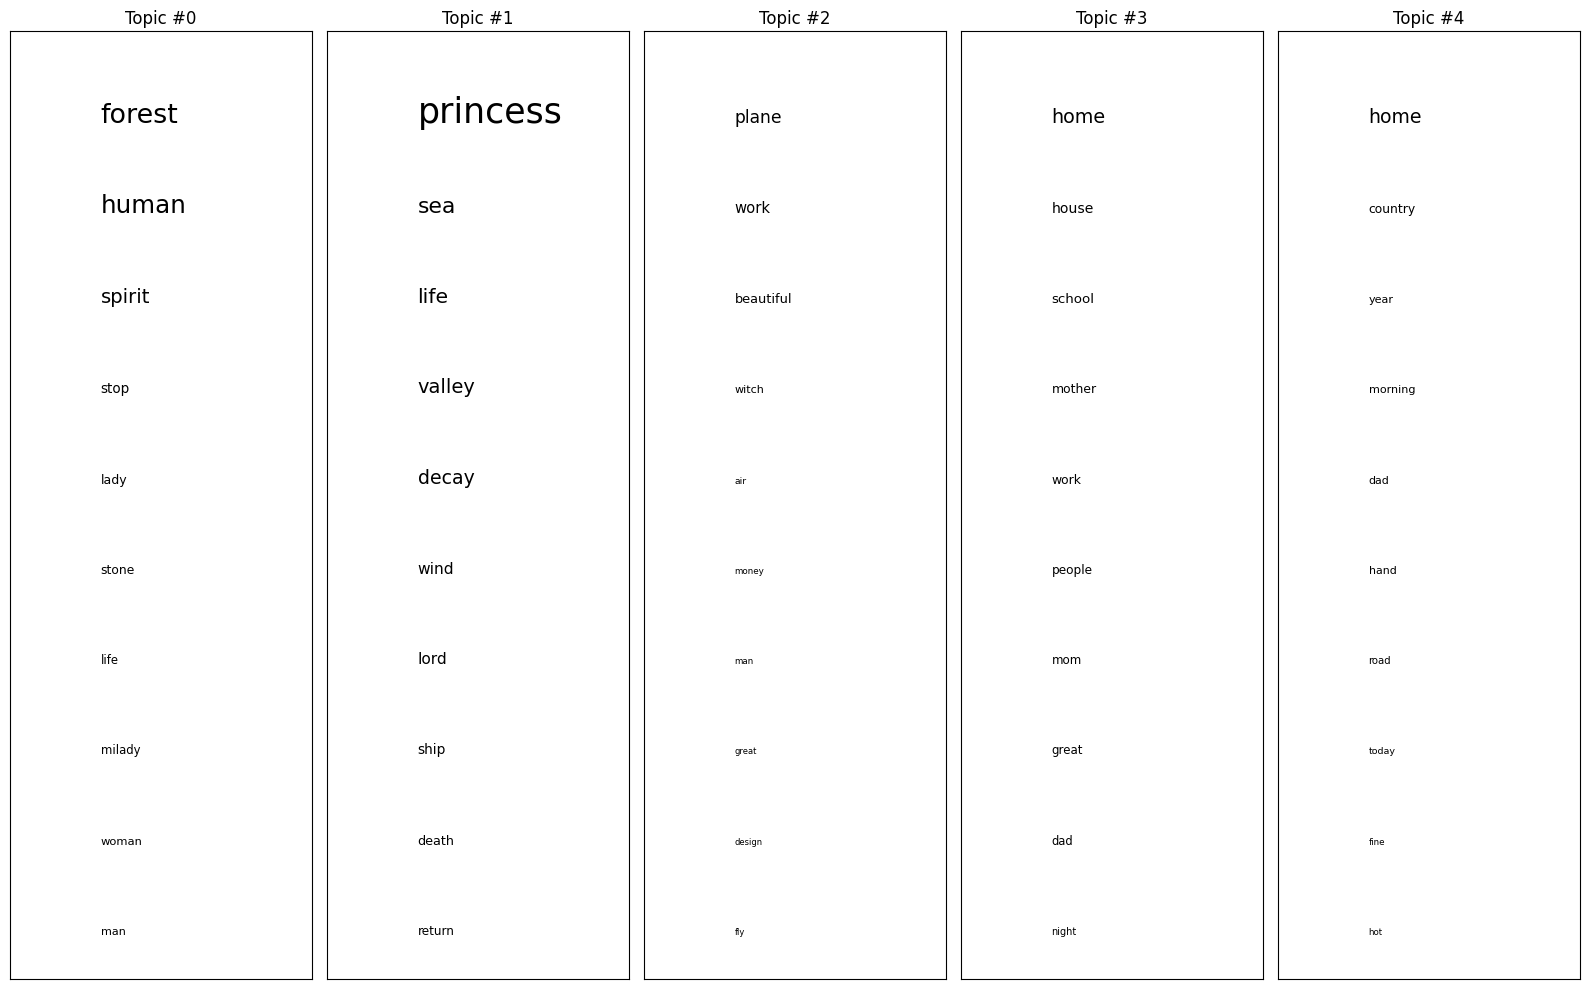

In [145]:
# Plot top words per topic

ghibli_fig = plt.figure(figsize=(16, 10))
num_top_words = 10


topic2top_words = dict(ghibli_movie_ldamodel.show_topics(formatted=False, num_words=num_top_words))
fontsize_base = 25 / max([w[0][1] for w in topic2top_words.values()])  

for topic, words_shares in topic2top_words.items():
    plt.subplot(1, ghibli_movie_ldamodel.num_topics, topic + 1)
    plt.ylim(0, num_top_words + 0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Topic #{topic}')
    for i, (word, share) in enumerate(words_shares):
        plt.text(0.3, num_top_words - i - 0.5, word, fontsize=fontsize_base * share)

plt.tight_layout()
plt.show()

## 3. Comparison between LDA Disney and LDA Studio Ghibli

### 3.1 Comparison of Coherence Scores

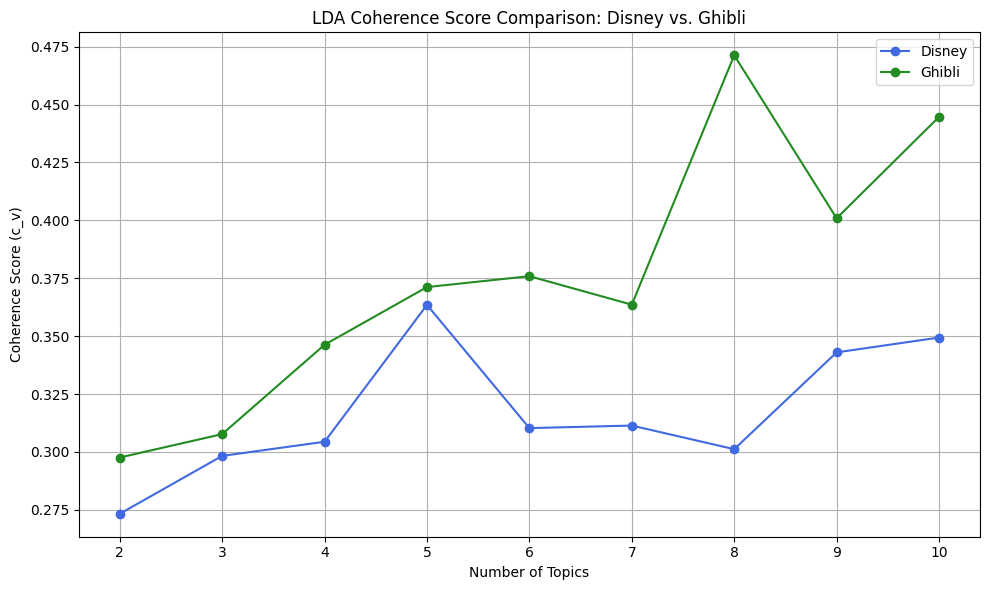

In [ ]:
# Plotting: Comparison Coherence Scores
plt.figure(figsize=(10, 6))
plt.plot(disney_topics, disney_coherence, marker='o', label='Disney', color='blue')
plt.plot(ghibli_topics, ghibli_coherence, marker='o', label='Ghibli', color='green')
plt.title('LDA Coherence Score Comparison: Disney vs. Ghibli')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.2 Comparison of Topics - Gender Differences

In [149]:
# lists of gender words
male_gender_words =    ["man",   "men",   "boy",    "son",    "prince",   "king",   "dad",   "he",  "wizard"]
female_gender_words =  ["woman", "women", "girl",   "daughter", "princess", "queen", "mom",  "she",  "witch"]

In [151]:
for word in male_gender_words + female_gender_words:
    if word in disney_movie_dictionary.token2id and word in ghibli_movie_dictionary.token2id:
        disney_topics = disney_movie_ldamodel.get_term_topics(word, minimum_probability=1e-3)
        ghibli_topics = ghibli_movie_ldamodel.get_term_topics(word, minimum_probability=1e-3)
        print(f"\nWord: {word}")
        print(f"  Disney: {disney_topics}")
        print(f"  Ghibli: {ghibli_topics}")
    else:
        print(f"\nWord: {word} not found in one or both dictionaries.")



Word: man
  Disney: [(0, 0.0023677482), (1, 0.0057181125), (2, 0.0067781503), (4, 0.0010021696), (5, 0.012742347), (6, 0.0035763471), (7, 0.001270596), (8, 0.00732526)]
  Ghibli: [(0, 0.009051671), (1, 0.002366185), (2, 0.0070855524), (4, 0.0014805159)]

Word: men
  Disney: [(1, 0.011690743), (2, 0.0033031672), (3, 0.0030135012), (8, 0.0023285623)]
  Ghibli: [(0, 0.0066290265), (2, 0.0031539458)]

Word: boy not found in one or both dictionaries.

Word: son
  Disney: [(0, 0.0015303282), (2, 0.0017408552), (5, 0.0064509367), (6, 0.00797215), (7, 0.0028735455), (8, 0.004527813)]
  Ghibli: [(2, 0.0019410561), (3, 0.0010219492), (4, 0.0018983334)]

Word: prince
  Disney: [(0, 0.004473993), (2, 0.024747934), (6, 0.0065579815), (7, 0.005017384), (8, 0.0010054128)]
  Ghibli: [(0, 0.0017741023), (2, 0.0010929938)]

Word: king not found in one or both dictionaries.

Word: dad
  Disney: [(3, 0.011083239), (5, 0.004789864), (7, 0.008076724)]
  Ghibli: [(3, 0.009437241), (4, 0.008980841)]

Word: h